In [2]:
import akshare as ak

import akshare as ak

stock_zh_a_hist_df = ak.stock_zh_a_hist(period="daily", start_date="20250501", end_date='20250512', adjust="qfq")
print(stock_zh_a_hist_df)

           日期    股票代码     开盘     收盘     最高     最低      成交量           成交额  \
0  2025-05-06  000001  10.92  10.96  11.00  10.89   854671  9.352121e+08   
1  2025-05-07  000001  11.01  11.03  11.04  10.97  1126270  1.240098e+09   
2  2025-05-08  000001  11.00  11.08  11.08  10.99  1056614  1.167913e+09   
3  2025-05-09  000001  11.07  11.15  11.17  11.06   999897  1.113688e+09   
4  2025-05-12  000001  11.16  11.16  11.22  11.13   895605  1.000478e+09   

     振幅   涨跌幅   涨跌额   换手率  
0  1.01  0.46  0.05  0.44  
1  0.64  0.64  0.07  0.58  
2  0.82  0.45  0.05  0.54  
3  0.99  0.63  0.07  0.52  
4  0.81  0.09  0.01  0.46  


In [10]:
import akshare as ak

stock_zh_a_spot_em_df = ak.stock_zh_a_spot_em()
print(stock_zh_a_spot_em_df)

  0%|          | 0/57 [00:00<?, ?it/s]

        序号      代码      名称    最新价    涨跌幅    涨跌额        成交量           成交额  \
0        1  873169    七丰精工  35.60  29.97   8.21   192071.0  5.968049e+08   
1        2  430425    乐创技术  38.31  22.28   6.98   112212.0  3.976427e+08   
2        3  301311    昆船智能  21.46  20.02   3.58   189117.0  3.802797e+08   
3        4  302132    中航成飞  95.86  20.01  15.98  1080629.0  9.739158e+09   
4        5  300946     恒而达  49.00  20.01   8.17    21310.0  1.044201e+08   
...    ...     ...     ...    ...    ...    ...        ...           ...   
5710  5711  000018    神城A退    NaN    NaN    NaN        NaN           NaN   
5711  5712  000015   PT中浩A    NaN    NaN    NaN        NaN           NaN   
5712  5713  000013  *ST石化A    NaN    NaN    NaN        NaN           NaN   
5713  5714  000005    ST星源    NaN    NaN    NaN        NaN           NaN   
5714  5715  000003   PT金田A    NaN    NaN    NaN        NaN           NaN   

         振幅     最高  ...    量比    换手率  市盈率-动态    市净率           总市值  \
0     38.59  35.60

In [11]:
stock_zh_a_spot_em_df[stock_zh_a_spot_em_df.名称=="东方财富"]

,序号,代码,名称,最新价,涨跌幅,涨跌额,成交量,成交额,振幅,最高,...,量比,换手率,市盈率-动态,市净率,总市值,流通市值,涨速,5分钟涨跌,60日涨跌幅,年初至今涨跌幅
453,454,300059,东方财富,21.72,4.27,0.89,5248646.0,1.124806e+10,5.18,21.97,...,1.58,3.93,31.57,4.16,3.428620e+11,2.901635e+11,0.0,-0.05,-9.05,-15.68


In [3]:
ak.stock_zh_a_spot()  ak.stock_zh_a_spot_em()

1

In [6]:
# 获取 A 股全部股票列表（包括主板、创业板、科创板）
stock_list_df = ak.stock_info_a_code_name()

  0%|          | 0/14 [00:00<?, ?it/s]

In [7]:
stock_list_df

,code,name
0,000001,平安银行
1,000002,万 科Ａ
2,000004,*ST国华
3,000006,深振业Ａ
4,000007,全新好
...,...,...
5406,920445,龙竹科技
5407,920489,佳先股份
5408,920682,球冠电缆
5409,920799,艾融软件


In [ ]:
stock_list_df

In [12]:
stock_zh_a_hist_tx_df = ak.stock_zh_a_hist(start_date="20250512", end_date="20250512", adjust="qfq")
print(stock_zh_a_hist_tx_df)

           日期    股票代码     开盘     收盘     最高     最低     成交量           成交额    振幅  \
0  2025-05-12  000001  11.16  11.16  11.22  11.13  895605  1.000478e+09  0.81   

    涨跌幅   涨跌额   换手率  
0  0.09  0.01  0.46  


In [ ]:
import akshare as ak
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

stock_list_df = ak.stock_info_a_code_name()
target_date = "20241201"
result_list = []

def fetch_stock_data(code):
    try:
        df = ak.stock_zh_a_hist(
            symbol=code,
            period="daily",
            start_date=target_date,
            end_date=target_date,
            adjust="qfq"
        )
        if not df.empty:
            df.insert(0, 'code', code)
            return df
    except Exception as e:
        return None

# 设置线程池大小，例如 20
with ThreadPoolExecutor(max_workers=20) as executor:
    futures = {executor.submit(fetch_stock_data, code): code for code in stock_list_df['code']}
    for future in as_completed(futures):
        data = future.result()
        if data is not None:
            result_list.append(data)

# 合并保存
all_data_df = pd.concat(result_list, ignore_index=True)

In [6]:
stock_zygc_em_df = ak.stock_zygc_em(symbol="SH688041")
print(stock_zygc_em_df)


      股票代码        报告日期   分类类型        主营构成          主营收入      收入比例  \
0   688041  2024-12-31    NaN      集成电路产品  9.134299e+09  0.996960   
1   688041  2024-12-31    NaN    集成电路技术服务  2.784906e+07  0.003040   
2   688041  2024-12-31  按产品分类       高端处理器  9.134299e+09  0.996960   
3   688041  2024-12-31  按产品分类        技术服务  2.784906e+07  0.003040   
4   688041  2024-12-31  按地区分类  境内(含港澳台地区)  9.162148e+09  1.000000   
..     ...         ...    ...         ...           ...       ...   
65  688041  2018-12-31  按产品分类      7000系列  4.205100e+07  0.871498   
66  688041  2018-12-31  按产品分类      5000系列  5.488900e+06  0.113756   
67  688041  2018-12-31  按产品分类      其他(补充)  7.115000e+05  0.014746   
68  688041  2018-12-31  按地区分类          华北  4.753990e+07  0.985254   
69  688041  2018-12-31  按地区分类      其他(补充)  7.115000e+05  0.014746   

            主营成本      成本比例          主营利润      利润比例       毛利率  
0   3.315922e+09  0.997567  5.818377e+09  0.996615  0.636981  
1   8.086971e+06  0.002433  1.976209e+07  0.0

In [7]:
stock_fund_flow_individual_df = ak.stock_fund_flow_individual(symbol="即时")
print(stock_fund_flow_individual_df)


  0%|          | 0/103 [00:00<?, ?it/s]

        序号    股票代码  股票简称     最新价      涨跌幅     换手率      流入资金      流出资金  \
0        1  301311  昆船智能   21.46   20.02%  21.68%     1.41亿     2.39亿   
1        2  302132  中航成飞   95.86   20.01%  18.29%    47.81亿    49.58亿   
2        3  300946   恒而达   49.00   20.01%   3.77%      0.00     1.04亿   
3        4  300607   拓斯达   37.18   20.01%  30.69%    17.25亿    19.38亿   
4        5  300581  晨曦航空   18.06   20.00%  27.57%    14.13亿    11.07亿   
...    ...     ...   ...     ...      ...     ...       ...       ...   
5119  5120  688266  泽璟制药   91.73   -7.80%   2.14%     2.41亿     2.85亿   
5120  5121    2853   皮阿诺   13.63   -7.84%   8.43%  7775.71万  7437.82万   
5121  5122  688235  百济神州  221.50   -9.04%   3.99%     4.91亿     5.36亿   
5122  5123  600793  宜宾纸业   22.56   -9.80%  10.21%     1.74亿     2.44亿   
5123  5124  688062  迈威生物   17.80  -10.96%  15.55%     2.26亿     3.24亿   

             净额     成交额  
0     -9842.89万   3.80亿  
1        -1.77亿  97.39亿  
2        -1.04亿   1.04亿  
3        -2.13亿  36

In [8]:
stock_individual_fund_flow_rank_df = ak.stock_individual_fund_flow_rank(indicator="今日")
print(stock_individual_fund_flow_rank_df)

  0%|          | 0/53 [00:00<?, ?it/s]

ConnectTimeout: HTTPSConnectionPool(host='push2delay.eastmoney.com', port=443): Max retries exceeded with url: /api/qt/clist/get?fid=f62&po=1&pz=100&pn=11&np=1&fltt=2&invt=2&ut=b2884a393a59ad64002292a3e90d46a5&fs=m%3A0%2Bt%3A6%2Bf%3A%212%2Cm%3A0%2Bt%3A13%2Bf%3A%212%2Cm%3A0%2Bt%3A80%2Bf%3A%212%2Cm%3A1%2Bt%3A2%2Bf%3A%212%2Cm%3A1%2Bt%3A23%2Bf%3A%212%2Cm%3A0%2Bt%3A7%2Bf%3A%212%2Cm%3A1%2Bt%3A3%2Bf%3A%212&fields=f12%2Cf14%2Cf2%2Cf3%2Cf62%2Cf184%2Cf66%2Cf69%2Cf72%2Cf75%2Cf78%2Cf81%2Cf84%2Cf87%2Cf204%2Cf205%2Cf124 (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x127997670>, 'Connection to push2delay.eastmoney.com timed out. (connect timeout=15)'))

In [10]:
stock_info_cjzc_em_df = ak.stock_info_cjzc_em()
print(stock_info_cjzc_em_df)

                   标题                                                 摘要  \
0    东方财富财经早餐 5月12日周一  【东方财富财经早餐 5月12日周一】1、中美经贸中方牵头人、国务院副总理何立峰：中美达成重要...   
1     东方财富财经早餐 5月9日周五  【东方财富财经早餐 5月9日周五】1、习近平同普京签署关于进一步深化中俄新时代全面战略协作伙...   
2     东方财富财经早餐 5月8日周四  【东方财富财经早餐 5月8日周四】1、美联储维持利率不变，鲍威尔：不急于降息，特朗普施压无影...   
3     东方财富财经早餐 5月7日周三  【东方财富财经早餐 5月7日周三】1、今日上午9时，央行、证监会等部门将举行发布会。2、特朗...   
4     东方财富财经早餐 5月6日周二  【东方财富财经早餐 5月6日周二】1、习近平主持召开部分省区市“十五五”时期经济社会发展座谈...   
..                ...                                                ...   
395  东方财富财经早餐 9月11日周一  【财经早餐】证监会近日召开专家学者和境内外投资者座谈会；中信证券等多家券商发布调整融资保证金...   
396   东方财富财经早餐 9月8日周五  【财经早餐】违规减持打击力度加大，监管正在研究处罚规则“痛感不强”问题；财政部副部长王东伟：...   
397   东方财富财经早餐 9月7日周四  【财经早餐】证监会：坚决贯彻党中央“要活跃资本市场，提振投资者信心”的重要部署；上交所就我乐...   
398   东方财富财经早餐 9月6日周三  【财经早餐】方星海谈期货行业高质量发展：加强对高频交易等新型交易行为的监管；郑州全面实施优化...   
399   东方财富财经早餐 9月5日周二  【财经早餐】国家主席习近平向2023中国国际智能产业博览会致贺信；国务院总理李强将出席二十国...   

                    发布时间                                                 链接  
0    2025

/var/folders/w5/1dk0jpjj4bgb8f3fzwqfptj40000gq/T/ipykernel_63850/4264848087.py:29: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w5/1dk0jpjj4bgb8f3fzwqfptj40000gq/T/ipykernel_63850/4264848087.py:29: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w5/1dk0jpjj4bgb8f3fzwqfptj40000gq/T/ipykernel_63850/4264848087.py:29: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w5/1dk0jpjj4bgb8f3fzwqfptj40000gq/T/ipykernel_63850/4264848087.py:29: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w5/1dk0jpjj4bgb8f3fzwqfptj40000gq/T/ipykernel_63850/4264848087.py:29: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w5/1dk0

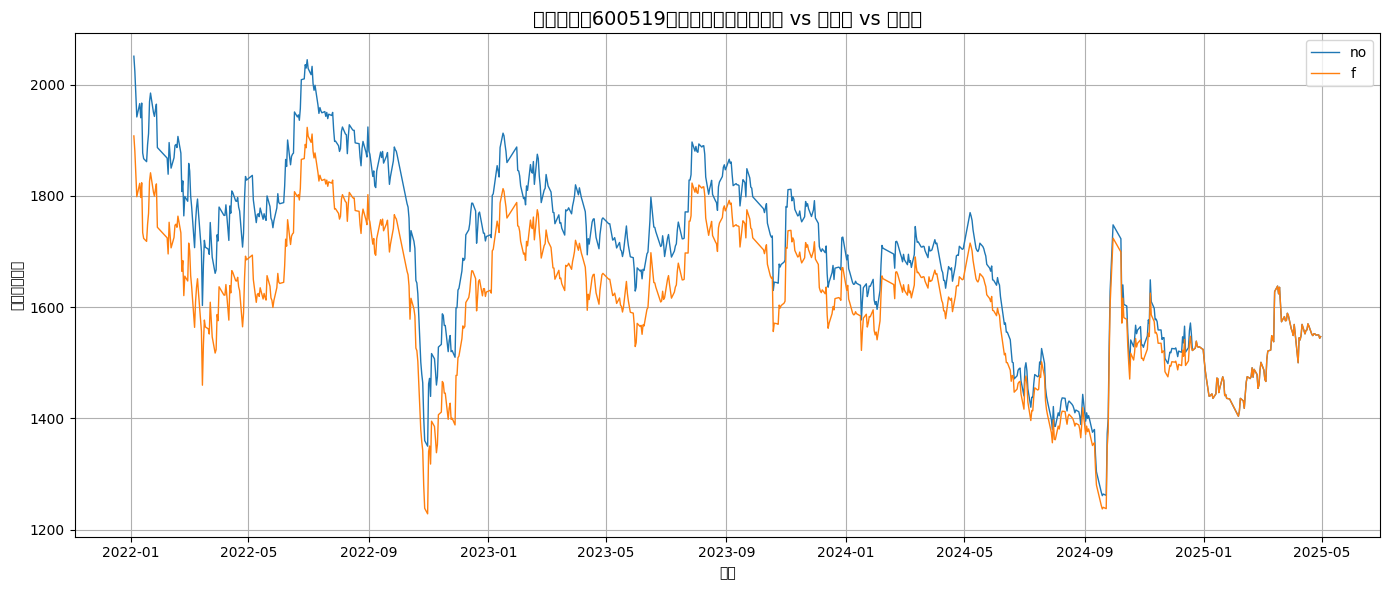

In [20]:


import akshare as ak
import matplotlib.pyplot as plt
import pandas as pd

symbol = "600519"
start_date = "20220101"
end_date = "20250501"

# 获取三种K线数据
df_raw = ak.stock_zh_a_hist(symbol=symbol, period="daily", start_date=start_date, end_date=end_date, adjust="")
df_qfq = ak.stock_zh_a_hist(symbol=symbol, period="daily", start_date=start_date, end_date=end_date, adjust="qfq")
df_hfq = ak.stock_zh_a_hist(symbol=symbol, period="daily", start_date=start_date, end_date=end_date, adjust="hfq")

# 时间字段格式化
df_raw["日期"] = pd.to_datetime(df_raw["日期"])
df_qfq["日期"] = pd.to_datetime(df_qfq["日期"])
df_hfq["日期"] = pd.to_datetime(df_hfq["日期"])

# 绘图
plt.figure(figsize=(14, 6))
plt.plot(df_raw["日期"], df_raw["收盘"], label="no", linewidth=1)
plt.plot(df_qfq["日期"], df_qfq["收盘"], label="f", linewidth=1)
# plt.plot(df_hfq["日期"], df_hfq["收盘"], label="h", linewidth=1)
plt.title("贵州茅台（600519）收盘价对比：不复权 vs 前复权 vs 后复权", fontsize=14)
plt.xlabel("日期")
plt.ylabel("收盘价（元）")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
